<class 'pandas.core.frame.DataFrame'>
Index: 1921 entries, 2 to 2141
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   region             1921 non-null   object 
 1   year               1921 non-null   int64  
 2   retail_per_capita  1921 non-null   float64
 3   region_standard    1921 non-null   object 
dtypes: float64(1), int64(1), object(2)
memory usage: 75.0+ KB
None

Missing values by column:
 region               0
year                 0
retail_per_capita    0
region_standard      0
dtype: int64

Number of unique regions: 85
Number of unique years: 22

Retail turnover per capita statistics:
 count      1921.000000
mean     106071.168142
std       79457.963548
min           0.000000
25%       32717.000000
50%       96377.000000
75%      164472.000000
max      477554.000000
Name: retail_per_capita, dtype: float64

Number of duplicates: 0

Number of outliers: 8

Top-5 observations:
          region_st

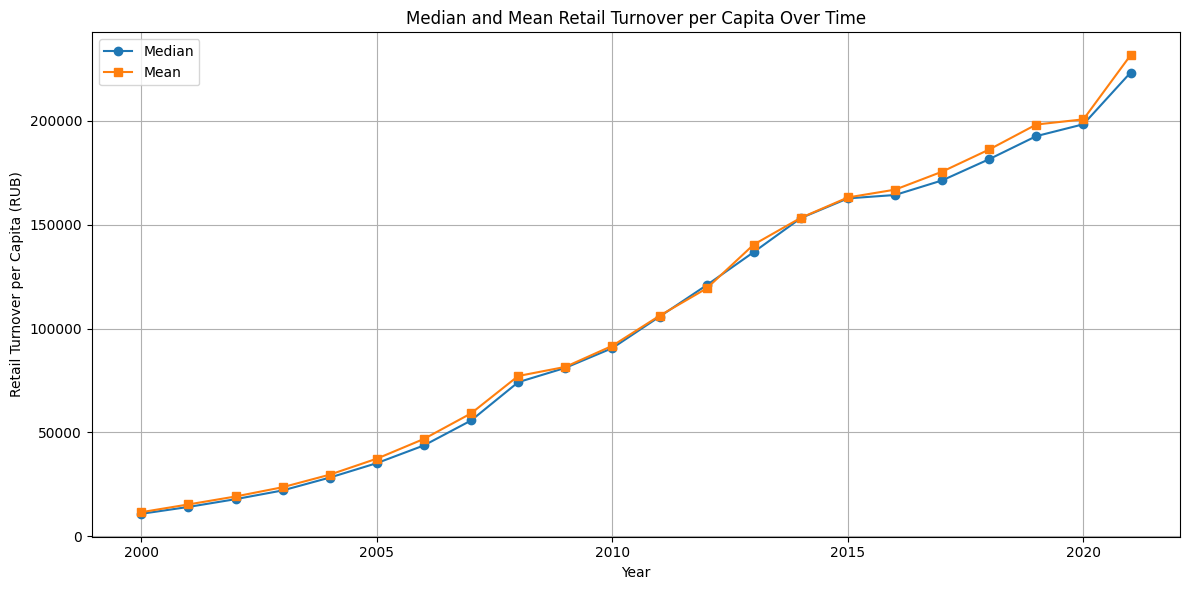

<Figure size 1600x600 with 0 Axes>

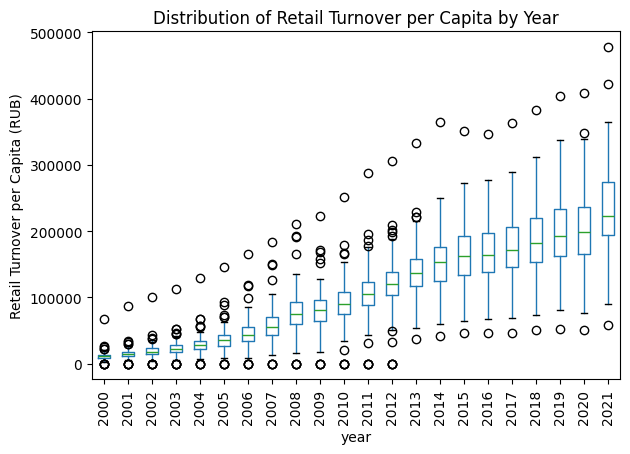

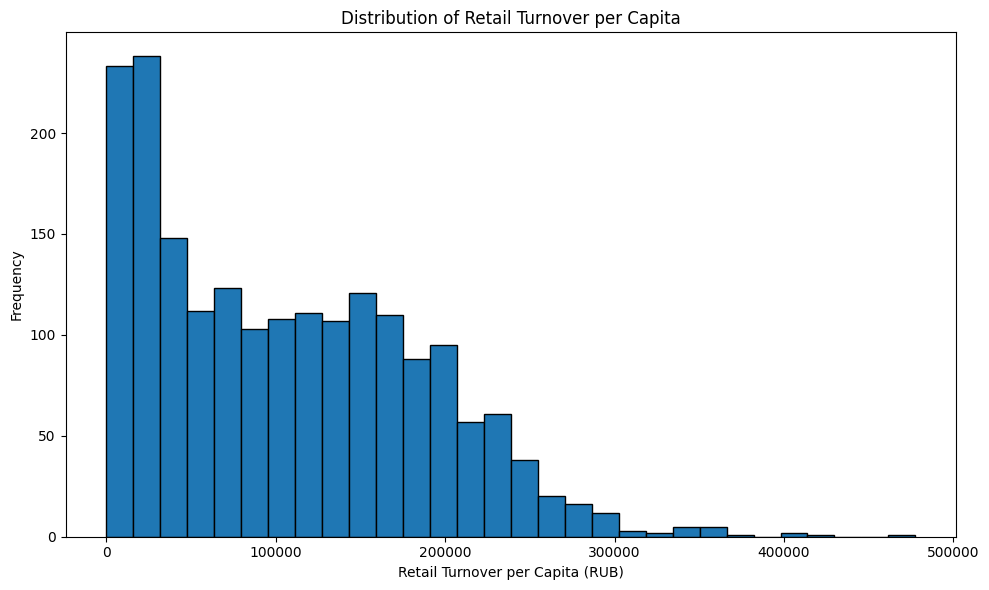

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load data
file_path = "../../outputs/standardized_datasets/retail_standardized.csv"
df = pd.read_csv(file_path)

# 2. Keep only rows with standardized region names
df = df[df["region_standard"].notna()].copy()

# 3. Check data quality
print(df.info())
print("\nMissing values by column:\n", df.isnull().sum())

# 4. Number of unique regions and years
print("\nNumber of unique regions:", df["region_standard"].nunique())
print("Number of unique years:", df["year"].nunique())

# 5. Summary statistics
print("\nRetail turnover per capita statistics:\n", df["retail_per_capita"].describe())

# 6. Duplicates
duplicates = df.duplicated().sum()
print("\nNumber of duplicates:", duplicates)

# 7. Outliers (IQR)
Q1 = df["retail_per_capita"].quantile(0.25)
Q3 = df["retail_per_capita"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df["retail_per_capita"] < lower_bound) |
    (df["retail_per_capita"] > upper_bound)
]

print("\nNumber of outliers:", outliers.shape[0])

# 8. Top-5 highest values
top5 = df.sort_values(by="retail_per_capita", ascending=False).head(5)
print("\nTop-5 observations:\n", top5[["region_standard", "year", "retail_per_capita"]])

# 9. Median and mean trends
median_turnover = df.groupby("year")["retail_per_capita"].median()
mean_turnover = df.groupby("year")["retail_per_capita"].mean()

plt.figure(figsize=(12,6))
plt.plot(median_turnover.index, median_turnover.values, marker="o", label="Median")
plt.plot(mean_turnover.index, mean_turnover.values, marker="s", label="Mean")
plt.title("Median and Mean Retail Turnover per Capita Over Time")
plt.xlabel("Year")
plt.ylabel("Retail Turnover per Capita (RUB)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 10. Boxplot
plt.figure(figsize=(16,6))
df.boxplot(column="retail_per_capita", by="year", grid=False, rot=90)
plt.title("Distribution of Retail Turnover per Capita by Year")
plt.suptitle("")
plt.ylabel("Retail Turnover per Capita (RUB)")
plt.tight_layout()
plt.show()

# 11. Histogram
plt.figure(figsize=(10,6))
plt.hist(df["retail_per_capita"], bins=30, edgecolor="black")
plt.title("Distribution of Retail Turnover per Capita")
plt.xlabel("Retail Turnover per Capita (RUB)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# EDA of `retail_standardized.csv`

## Data Description
- The dataset contains 1,921 observations across 85 regions.
- Time coverage spans 22 years.
- Key variable: retail turnover per capita (RUB).

---

## Data Types
- All variables are correctly formatted:
  - `year`: int64  
  - `retail_per_capita`: float64  
  - `region_standard`: object  

---

## Missing Values
- No missing values remain after removing aggregated observations.

---

## Duplicates
- No duplicate records were found.

---

## Summary Statistics
- Mean: ~106,000 RUB  
- Median: ~96,000 RUB  
- Maximum: ~477,500 RUB  
- 75% of observations are below ~164,500 RUB  
- Minimum: 0 RUB  

The difference between mean and median indicates a right-skewed distribution driven by high-consumption regions.

---

## Top-5 Observations
1. Moscow (2021) — 477,554 RUB  
2. Moscow Oblast (2021) — 422,211 RUB  
3. Moscow (2020) — 408,674 RUB  
4. Moscow (2019) — 403,426 RUB  
5. Moscow (2018) — 382,016 RUB  

---

## Outliers
- Number of outliers (IQR): 8 observations.  
- All outliers correspond to economically strong regions.  
- These values are retained, as they reflect real differences in consumption patterns.  

---

## Trends Over Time
- Median retail turnover per capita increases steadily over time.  
- The mean is consistently higher than the median due to a few high-value regions (e.g., Moscow).  
- The gap between mean and median widens, indicating growing regional inequality in consumption.  

---

## Distribution Patterns
- Boxplots show a strong right-skewed distribution with a long upper tail.  
- Most regions fall below ~160,000 RUB, while a few regions significantly exceed this level.  

---

## Interpretation
- Retail turnover per capita reflects consumer behavior and purchasing power.  
- Higher values are associated with wealthier, more urbanized regions.  
- The increasing gap between regions suggests divergence in living standards and economic activity.  

This variable complements income and GRP by capturing the **consumption side of the economy**.

---

## Modeling Considerations
- Due to skewness, transformation (e.g., logarithmic scaling) is recommended.  
- Robust methods may also help reduce the influence of extreme values.  

---

## Conclusion
The dataset is clean and ready for further analysis.

Retail turnover per capita provides a key economic signal and is expected to contribute significantly to clustering by differentiating regions based on consumption levels.

In [2]:
df.to_csv("../../data/clean/retail_AfterEDA.csv", index=False)